# EDA

Exploring the credit card fraud dataset before preprocessing. Loads the data, checks class imbalance, looks at transaction amount and time patterns, and checks which features separate fraud from legitimate transactions.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy as stats
import warnings
warnings.filterwarnings("ignore")

In [2]:
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("husl")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: "%.4f" % x)

Loading the raw data.

In [3]:
df=pd.read_csv("../data/creditcard.csv")

In [4]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0000,-1.3598,-0.0728,2.5363,1.3782,-0.3383,0.4624,0.2396,0.0987,0.3638,0.0908,-0.5516,-0.6178,-0.9914,-0.3112,1.4682,-0.4704,0.2080,0.0258,0.4040,0.2514,-0.0183,0.2778,-0.1105,0.0669,0.1285,-0.1891,0.1336,-0.0211,149.6200,0
1,0.0000,1.1919,0.2662,0.1665,0.4482,0.0600,-0.0824,-0.0788,0.0851,-0.2554,-0.1670,1.6127,1.0652,0.4891,-0.1438,0.6356,0.4639,-0.1148,-0.1834,-0.1458,-0.0691,-0.2258,-0.6387,0.1013,-0.3398,0.1672,0.1259,-0.0090,0.0147,2.6900,0
2,1.0000,-1.3584,-1.3402,1.7732,0.3798,-0.5032,1.8005,0.7915,0.2477,-1.5147,0.2076,0.6245,0.0661,0.7173,-0.1659,2.3459,-2.8901,1.1100,-0.1214,-2.2619,0.5250,0.2480,0.7717,0.9094,-0.6893,-0.3276,-0.1391,-0.0554,-0.0598,378.6600,0
3,1.0000,-0.9663,-0.1852,1.7930,-0.8633,-0.0103,1.2472,0.2376,0.3774,-1.3870,-0.0550,-0.2265,0.1782,0.5078,-0.2879,-0.6314,-1.0596,-0.6841,1.9658,-1.2326,-0.2080,-0.1083,0.0053,-0.1903,-1.1756,0.6474,-0.2219,0.0627,0.0615,123.5000,0
4,2.0000,-1.1582,0.8777,1.5487,0.4030,-0.4072,0.0959,0.5929,-0.2705,0.8177,0.7531,-0.8228,0.5382,1.3459,-1.1197,0.1751,-0.4514,-0.2370,-0.0382,0.8035,0.4085,-0.0094,0.7983,-0.1375,0.1413,-0.2060,0.5023,0.2194,0.2152,69.9900,0


In [5]:
print(f"dataset shape:{df.shape}")

dataset shape:(284807, 31)


Checking class imbalance. Fraud is a very small share of transactions.

In [6]:
print(f"class distribution:\n{df['Class'].value_counts()}")
print(f"fraud percentage:\n{df['Class'].mean()*100}%")

class distribution:
Class
0    284315
1       492
Name: count, dtype: int64
fraud percentage:
0.1727485630620034%


Checking transaction amount by class.

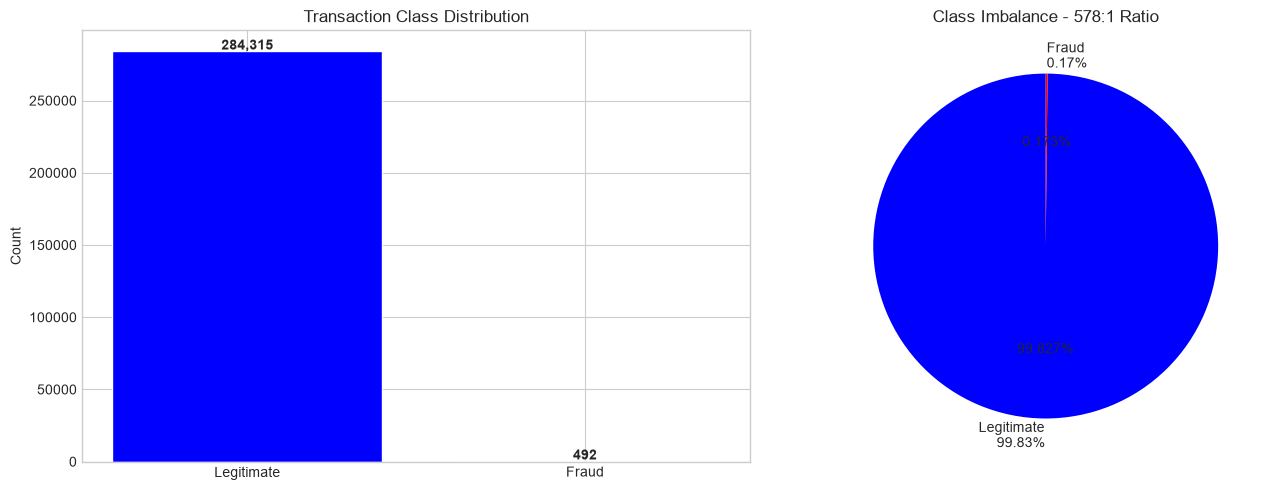

In [7]:
# Class imbalance visualization
fig,axes=plt.subplots(1,2,figsize=(14,5))
# Class distribution
class_counts = df['Class'].value_counts()

colors = ['blue', 'red']
axes[0].bar(['Legitimate', 'Fraud'],
            class_counts.values,
            color=colors, 
            edgecolor='white')
axes[0].set_title('Transaction Class Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 1000,
                 f'{v:,}', 
                 ha='center', 
                 fontweight='bold')


axes[1].pie(class_counts.values,
            labels=['Legitimate\n99.83%', 'Fraud\n0.17%'],
            colors=colors,
            autopct='%1.3f%%',
            startangle=90)  
axes[1].set_title('Class Imbalance - 578:1 Ratio')

plt.tight_layout()
plt.savefig('../results/class_imbalance.png', dpi=150, bbox_inches='tight')
plt.show()

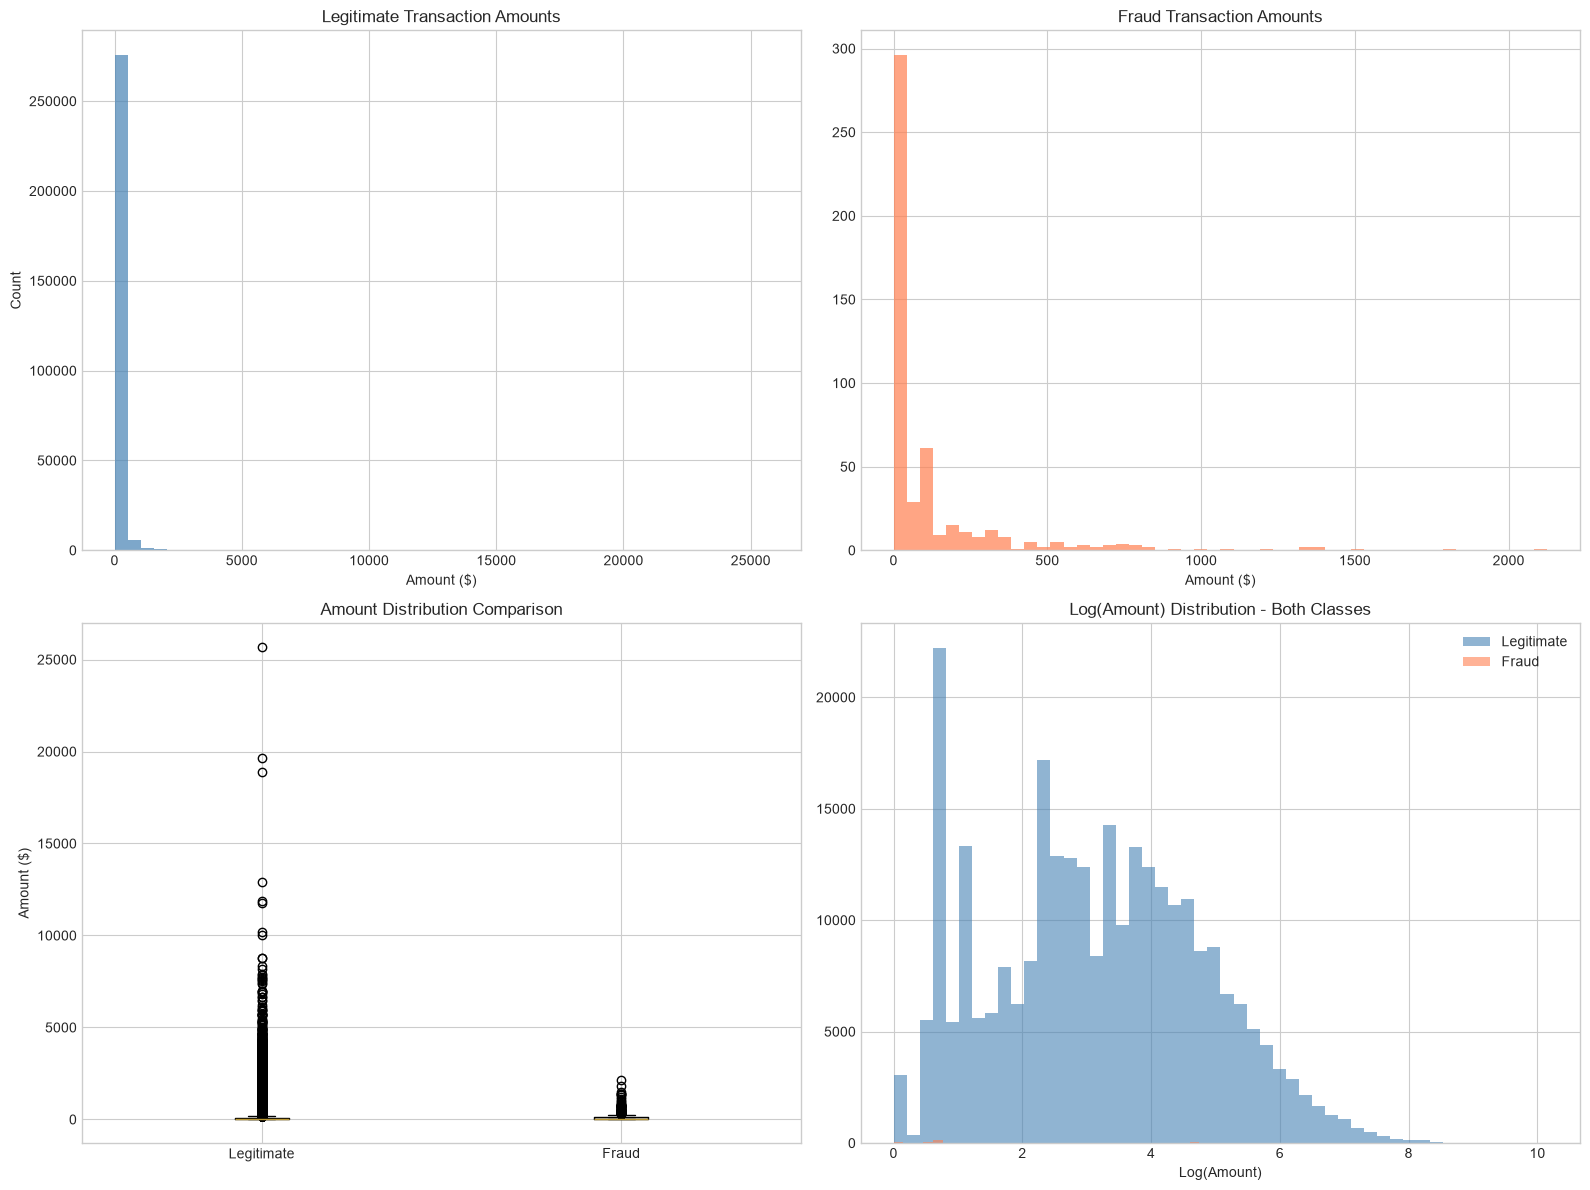

In [8]:
#Transaction amount analysis
fig,axes = plt.subplots(2, 2, figsize=(16, 12))
# Amount distribution - legitimate
axes[0,0].hist(df[df["Class"]==0]["Amount"],
               bins=50,
               color="steelblue",
               alpha=0.7)
axes[0,0].set_title('Legitimate Transaction Amounts')
axes[0,0].set_xlabel('Amount ($)')
axes[0,0].set_ylabel('Count')
# Amount distribution - fraud
axes[0,1].hist(df[df['Class']==1]['Amount'],
               bins=50, 
               color='coral',
               alpha=0.7)
axes[0,1].set_title('Fraud Transaction Amounts')
axes[0,1].set_xlabel('Amount ($)')

# Boxplot comparison
axes[1,0].boxplot([df[df['Class']==0]['Amount'],
                   df[df['Class']==1]['Amount']],
                  tick_labels=['Legitimate', 'Fraud'])
axes[1,0].set_title('Amount Distribution Comparison')
axes[1,0].set_ylabel('Amount ($)')

# Log scale comparison
axes[1,1].hist(np.log1p(df[df['Class']==0]['Amount']),
               bins=50,
               color='steelblue',
               alpha=0.6, 
               label='Legitimate')
axes[1,1].hist(np.log1p(df[df['Class']==1]['Amount']),
               bins=50,
               color='coral', 
               alpha=0.6, 
               label='Fraud')
axes[1,1].set_title('Log(Amount) Distribution - Both Classes')
axes[1,1].set_xlabel('Log(Amount)')
axes[1,1].legend()
plt.tight_layout()
plt.savefig('../results/amount_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


Checking transaction time by class, converted from seconds to hour of day.

In [9]:
print("Legitimate transactions:")
print(df[df['Class']==0]['Amount'].describe())
print("\nFraud transactions:")
print(df[df['Class']==1]['Amount'].describe())

Legitimate transactions:
count   284315.0000
mean        88.2910
std        250.1051
min          0.0000
25%          5.6500
50%         22.0000
75%         77.0500
max      25691.1600
Name: Amount, dtype: float64

Fraud transactions:
count    492.0000
mean     122.2113
std      256.6833
min        0.0000
25%        1.0000
50%        9.2500
75%      105.8900
max     2125.8700
Name: Amount, dtype: float64


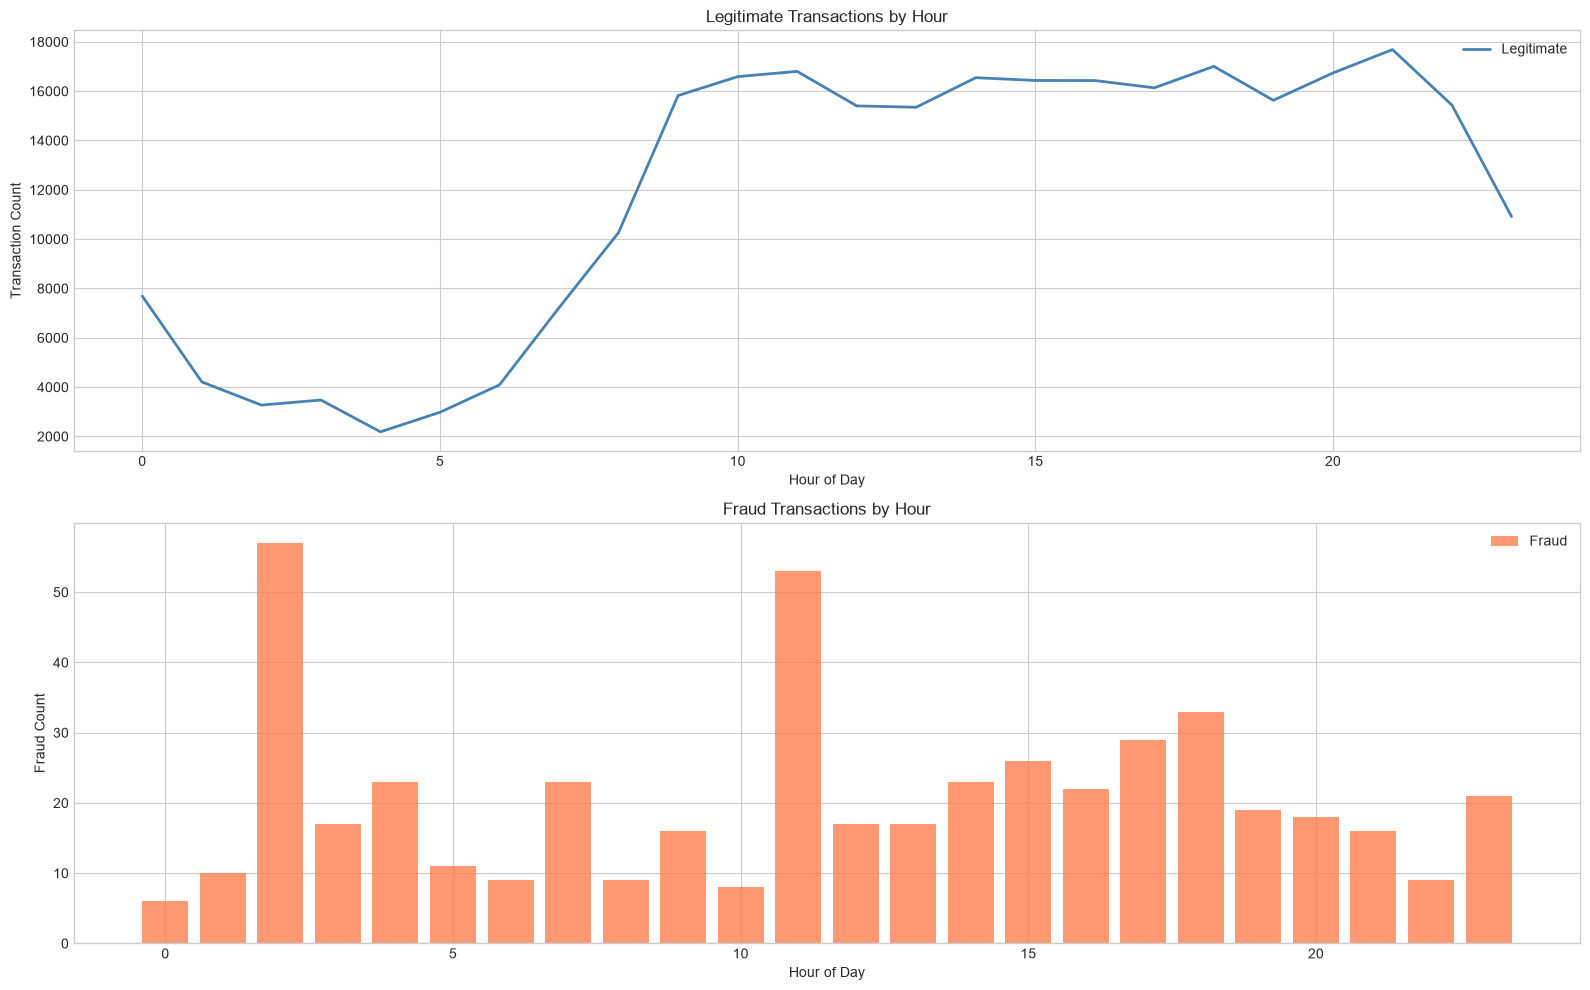

In [10]:
#Time analysis
fig,axes=plt.subplots(2,1,figsize=(16,10))
# time conversion from sec to hr
df["Hour"]=(df["Time"]/3600)%24

# Transaction volume by hour
legitimate_by_hour=df[df["Class"]==0].groupby(df[df['Class']==0]['Hour'].astype(int))['Class'].count()

axes[0].plot(legitimate_by_hour.index, legitimate_by_hour.values,
             color='steelblue', label='Legitimate', linewidth=2)
axes[0].set_title('Legitimate Transactions by Hour')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Transaction Count')
axes[0].legend()

fraud_by_hour = df[df['Class']==1].groupby(df[df['Class']==1]['Hour'].astype(int))['Class'].count()
axes[1].bar(fraud_by_hour.index, fraud_by_hour.values,
            color='coral', alpha=0.8, label='Fraud')
axes[1].set_title('Fraud Transactions by Hour')
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Fraud Count')
axes[1].legend()
plt.tight_layout()
plt.savefig('../results/time_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


Checking which of the PCA features (V1-V28) separate fraud from legitimate transactions the most.

In [11]:
# Fraud rate by hour
df['FraudRate'] = df.groupby(df['Hour'].astype(int))['Class'].transform('mean')
print("Highest fraud rate hours:")
print(df.groupby(df['Hour'].astype(int))['Class'].mean().sort_values(
    ascending=False).head(5))

Highest fraud rate hours:
Hour
2   0.0171
4   0.0104
3   0.0049
5   0.0037
7   0.0032
Name: Class, dtype: float64


In [12]:
#PCA features analysis
pca_features = [f'V{i}' for i in range(1, 29)]
fraud_means = df[df['Class']==1][pca_features].mean()
legit_means = df[df['Class']==0][pca_features].mean()
mean_diff = (fraud_means - legit_means).abs().sort_values(ascending=False)
print("Top 10 features separating fraud from legitimate:")
print(mean_diff.head(10))

Top 10 features separating fraud from legitimate:
V3    7.0455
V14   6.9838
V17   6.6774
V12   6.2702
V10   5.6867
V7    5.5784
V1    4.7802
V4    4.5499
V16   4.1471
V11   3.8067
dtype: float64


Checking correlation of all features with the fraud label.

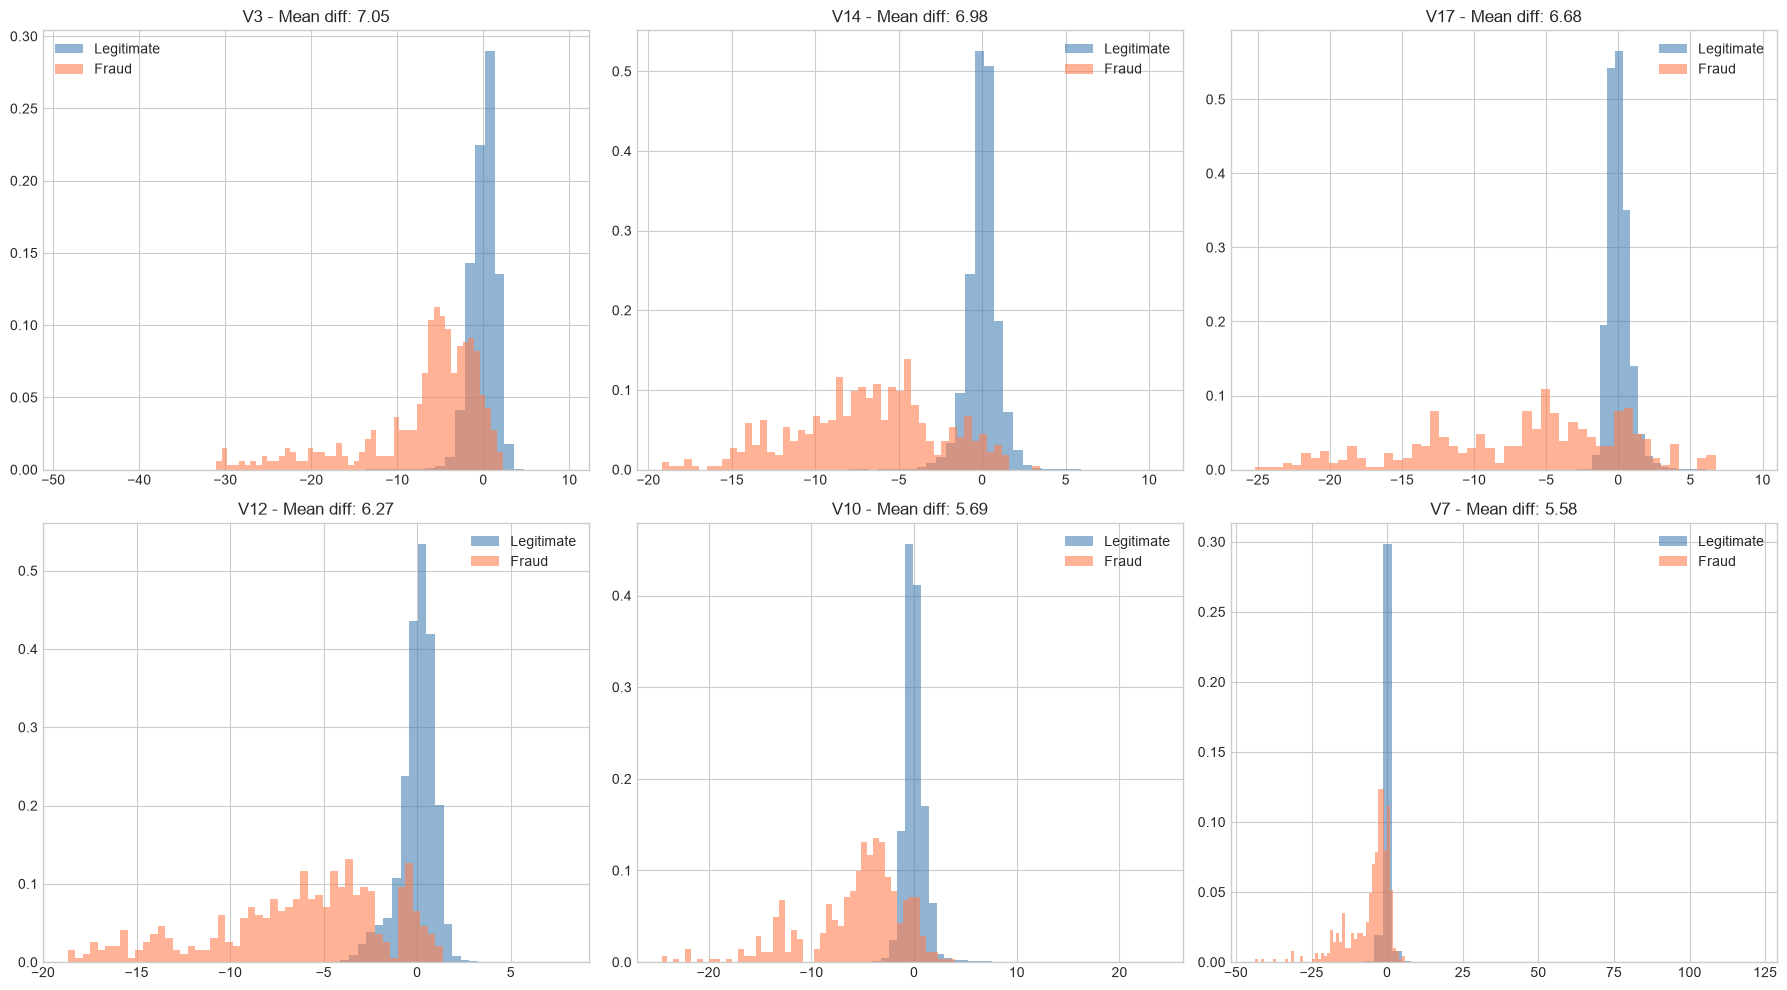

In [13]:
top_features = mean_diff.head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for i, feature in enumerate(top_features):
    axes[i].hist(df[df['Class']==0][feature],
                 bins=50, color='steelblue', alpha=0.6,
                 label='Legitimate', density=True)
    axes[i].hist(df[df['Class']==1][feature],
                 bins=50, color='coral', alpha=0.6,
                 label='Fraud', density=True)
    axes[i].set_title(f'{feature} - Mean diff: {mean_diff[feature]:.2f}')
    axes[i].legend()
    
    
plt.tight_layout()
plt.savefig('../results/pca_features.png', dpi=150, bbox_inches='tight')
plt.show()    

Running a Mann-Whitney U test on each PCA feature to check if the difference between fraud and legitimate is statistically significant.

Top 15 features correlated with fraud:
V17         0.3265
V14         0.3025
V12         0.2606
V10         0.2169
V16         0.1965
V3          0.1930
V7          0.1873
V11         0.1549
V4          0.1334
V18         0.1115
V1          0.1013
V9          0.0977
V5          0.0950
V2          0.0913
FraudRate   0.0487
Name: Class, dtype: float64


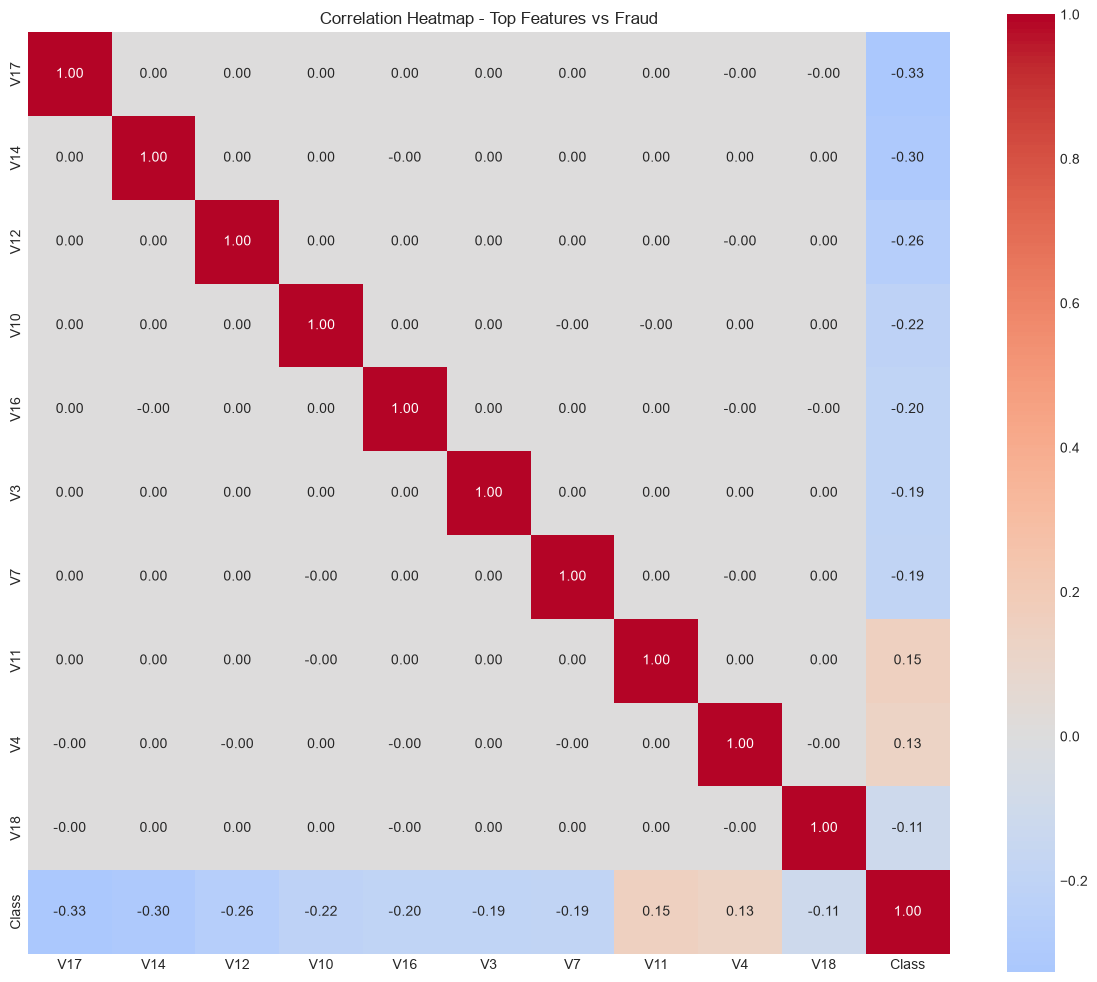

In [14]:
#correlation analysis
correlations = df.corr()['Class'].drop('Class').abs().sort_values(ascending=False)
print("Top 15 features correlated with fraud:")
print(correlations.head(15))
top_corr = correlations.head(10).index.tolist() + ['Class']
plt.figure(figsize=(12, 10))
sns.heatmap(df[top_corr].corr(),
            annot=True, fmt='.2f',
            cmap='coolwarm', center=0,
            square=True)
plt.title('Correlation Heatmap - Top Features vs Fraud')
plt.tight_layout()
plt.savefig('../results/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

Final data checks, missing values and duplicate rows, and a summary of what was found.

In [15]:
from scipy.stats import mannwhitneyu
# Are the differences between fraud and legitimate statistically significant?

print("Mann-Whitney U Test - Fraud vs Legitimate")
print("=" * 50)
print(f"{'Feature':<10} {'p-value':>15} {'Significant':>12}")
print("=" * 50)

for feature in pca_features:
    fraud_vals = df[df['Class']==1][feature]
    legit_vals = df[df['Class']==0][feature]
    stat, p_value = mannwhitneyu(fraud_vals, legit_vals, alternative='two-sided')
    significant = "YES yes" if p_value < 0.05 else "NO no"
    print(f"{feature:<10} {p_value:>15.2e} {significant:>12}")

Mann-Whitney U Test - Fraud vs Legitimate
Feature            p-value  Significant
V1               1.74e-113      YES yes
V2               1.65e-163      YES yes
V3               1.21e-219      YES yes
V4               3.63e-248      YES yes
V5                3.05e-58      YES yes
V6                2.23e-93      YES yes
V7               1.46e-146      YES yes
V8                8.51e-34      YES yes
V9               8.94e-154      YES yes
V10              9.61e-222      YES yes
V11              4.91e-226      YES yes
V12              8.42e-247      YES yes
V13               5.12e-02        NO no
V14              1.47e-260      YES yes
V15               1.30e-01        NO no
V16              1.81e-156      YES yes
V17              9.22e-124      YES yes
V18               2.65e-77      YES yes
V19               2.40e-33      YES yes
V20               1.13e-30      YES yes
V21               8.67e-80      YES yes
V22               2.66e-01        NO no
V23               7.42e-03      YES ye

In [16]:
# Check data 
print("Missing values:")
print(df.isnull().sum().sum())

print(f"\nDataset info:")
print(f"Shape: {df.shape}")
print(f"Memory usage: {df.memory_usage().sum() / 1024**2:.1f} MB")
print(f"\nData types:")
print(df.dtypes.value_counts())

# Check for duplicates
duplicates = df.duplicated().sum()
print(f"\nDuplicate rows: {duplicates}")
if duplicates > 0:
    print("Removing duplicates...")
    df = df.drop_duplicates()
    print(f"New shape: {df.shape}")

Missing values:
0

Dataset info:
Shape: (284807, 33)
Memory usage: 71.7 MB

Data types:
float64    32
int64       1
Name: count, dtype: int64

Duplicate rows: 1081
Removing duplicates...
New shape: (283726, 33)


In [17]:
print("=" * 60)
print("EDA SUMMARY - Credit Card Fraud Detection")
print("=" * 60)
print(f"Total transactions:     {len(df):,}")
print(f"Legitimate:             {(df['Class']==0).sum():,}")
print(f"Fraud:                  {(df['Class']==1).sum():,}")
print(f"Fraud rate:             {df['Class'].mean()*100:.4f}%")
print(f"Imbalance ratio:        {(df['Class']==0).sum()/(df['Class']==1).sum():.0f}:1")
print(f"\nAmount statistics:")
print(f"Max legitimate:         ${df[df['Class']==0]['Amount'].max():,.2f}")
print(f"Max fraud:              ${df[df['Class']==1]['Amount'].max():,.2f}")
print(f"Mean legitimate:        ${df[df['Class']==0]['Amount'].mean():,.2f}")
print(f"Mean fraud:             ${df[df['Class']==1]['Amount'].mean():,.2f}")
print(f"\nMost discriminative features: {mean_diff.head(3).index.tolist()}")
print(f"Missing values:         {df.isnull().sum().sum()}")
print(f"Duplicate rows:         {duplicates}")
print("=" * 60)

EDA SUMMARY - Credit Card Fraud Detection
Total transactions:     283,726
Legitimate:             283,253
Fraud:                  473
Fraud rate:             0.1667%
Imbalance ratio:        599:1

Amount statistics:
Max legitimate:         $25,691.16
Max fraud:              $2,125.87
Mean legitimate:        $88.41
Mean fraud:             $123.87

Most discriminative features: ['V3', 'V14', 'V17']
Missing values:         0
Duplicate rows:         1081
